# NLP in Cancer Pathology Reports
### Using Traditional NLP, SciBERT, BioBERT, Ensemble and ChatGPT
**Student:** Hemanth Araja · **ID:** 213069235 · **Professor:** Bin Tang · **CSUDH**
**Dataset:** TCGA (9,523 Pathology Reports · 32 Cancer Types)

## Step 1 · Install & Import Libraries

In [31]:
!pip install pandas numpy scikit-learn nltk transformers torch datasets matplotlib seaborn openai scipy

In [32]:
import pandas as pd
import numpy as np
import re, os
import nltk
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import openai
import warnings
warnings.filterwarnings("ignore")

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack, csr_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

# ── Device ─────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
else:
    print("No GPU — for SciBERT/BioBERT 90%+ accuracy, run on Google Colab T4 GPU")
print("All libraries imported successfully!")

Device : cuda
GPU    : Tesla T4
All libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Step 2 · Load FULL Dataset - All 9,523 reports
Using the **complete TCGA dataset**




In [33]:
from google.colab import files
uploaded = files.upload()

Saving TCGA_Reports.csv to TCGA_Reports (2).csv


In [34]:
CSV_PATH = "TCGA_Reports.csv"

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"Could not find '{CSV_PATH}'. Please check the path.")

reports = pd.read_csv(CSV_PATH)
print(f"Shape   : {reports.shape}")
print(f"Columns : {list(reports.columns)}")
reports.head()

Shape   : (9523, 2)
Columns : ['patient_filename', 'text']


,patient_filename,text
0,TCGA-BP-5195.25c0b433-5557-4165-922e-2c1eac9c26f0,Date of Recelpt: Clinical Diagnosis & History:...
1,TCGA-D7-8573.b7306a47-697d-4ed3-bbe1-81d49674a8f8,"Material: 1) Material: stomach, Method of coll..."
2,TCGA-EI-7004.13591eed-30e5-47a3-91be-7a370663d2d4,page 1 / 1. copy No. 3. Examination: Histopath...
3,TCGA-EB-A82B.23E186C6-739C-4EF1-8788-79AA89C6E87A,Patient ID: Gross Description: A mass is locat...
4,TCGA-A6-3808.e1505f65-72ef-438d-a5e1-93ed8bf6635d,SPECIMEN. Right colon. CLINICAL NOTES. PRE-OP ...


In [35]:
reports["patient_id"] = reports["patient_filename"].str[:12]
print(f"Total reports loaded: {len(reports)}")
reports.head()

Total reports loaded: 9523


,patient_filename,text,patient_id
0,TCGA-BP-5195.25c0b433-5557-4165-922e-2c1eac9c26f0,Date of Recelpt: Clinical Diagnosis & History:...,TCGA-BP-5195
1,TCGA-D7-8573.b7306a47-697d-4ed3-bbe1-81d49674a8f8,"Material: 1) Material: stomach, Method of coll...",TCGA-D7-8573
2,TCGA-EI-7004.13591eed-30e5-47a3-91be-7a370663d2d4,page 1 / 1. copy No. 3. Examination: Histopath...,TCGA-EI-7004
3,TCGA-EB-A82B.23E186C6-739C-4EF1-8788-79AA89C6E87A,Patient ID: Gross Description: A mass is locat...,TCGA-EB-A82B
4,TCGA-A6-3808.e1505f65-72ef-438d-a5e1-93ed8bf6635d,SPECIMEN. Right colon. CLINICAL NOTES. PRE-OP ...,TCGA-A6-3808


## Step 3 · Load Cancer Type Labels

In [36]:
cancer_url = "https://raw.githubusercontent.com/tatonetti-lab/tcga-path-reports/main/data/tcga_metadata/tcga_patient_to_cancer_type.csv"
cancer = pd.read_csv(cancer_url)
cancer = cancer.rename(columns={
    "bcr_patient_barcode": "patient_id",
    "type": "cancer_type"
})
print(f"Cancer labels shape: {cancer.shape}")
cancer.head()

Cancer labels shape: (11160, 2)


,patient_id,cancer_type
0,TCGA-OR-A5J1,ACC
1,TCGA-OR-A5J2,ACC
2,TCGA-OR-A5J3,ACC
3,TCGA-OR-A5J4,ACC
4,TCGA-OR-A5J5,ACC


## Step 4 · Merge Datasets

In [37]:
data = reports.merge(cancer, on="patient_id")
data = data[["text", "cancer_type"]].dropna().reset_index(drop=True)

print(f" Total records after merge : {len(data)}  (FULL dataset — all 9,523 reports)")
print(f"Unique cancer types          : {data['cancer_type'].nunique()}")
data.head()

✅ Total records after merge : 9523  (FULL dataset — all 9,523 reports)
Unique cancer types          : 32


,text,cancer_type
0,Date of Recelpt: Clinical Diagnosis & History:...,KIRC
1,"Material: 1) Material: stomach, Method of coll...",STAD
2,page 1 / 1. copy No. 3. Examination: Histopath...,READ
3,Patient ID: Gross Description: A mass is locat...,SKCM
4,SPECIMEN. Right colon. CLINICAL NOTES. PRE-OP ...,COAD


## Step 5 · Exploratory Data Analysis

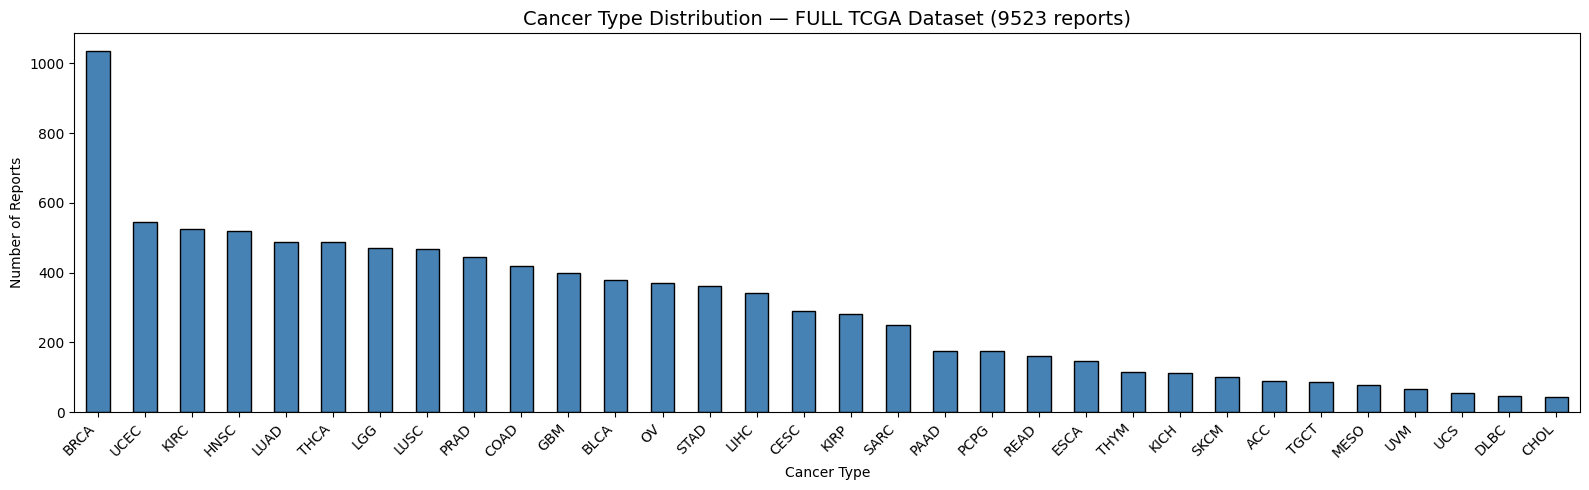

Total cancer types: 32
cancer_type
BRCA    1034
UCEC     546
KIRC     525
HNSC     520
LUAD     488
THCA     487
LGG      469
LUSC     468
PRAD     446
COAD     418
GBM      399
BLCA     379
OV       371
STAD     361
LIHC     341
CESC     289
KIRP     280
SARC     249
PAAD     176
PCPG     174
READ     162
ESCA     146
THYM     114
KICH     112
SKCM     102
ACC       90
TGCT      87
MESO      79
UVM       65
UCS       56
DLBC      47
CHOL      43
Name: count, dtype: int64


In [38]:
plt.figure(figsize=(16, 5))
data['cancer_type'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title(f'Cancer Type Distribution — FULL TCGA Dataset ({len(data)} reports)', fontsize=14)
plt.xlabel('Cancer Type')
plt.ylabel('Number of Reports')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(f"Total cancer types: {data['cancer_type'].nunique()}")
print(data['cancer_type'].value_counts())

## Step 6 · Text Preprocessing

In [39]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

data["clean_text"] = data["text"].apply(clean_text)
print("Text cleaning complete.")
print("\nOriginal sample:")
print(data["text"].iloc[0][:200])
print("\nCleaned sample:")
print(data["clean_text"].iloc[0][:200])

Text cleaning complete.

Original sample:
Date of Recelpt: Clinical Diagnosis & History: Incidental 3 cm left upper pole renal mass. Specimens Submitted: 1: Kidney, Left Upper Pole; Partial Nephrectomy. DIAGNOSIS: 1. Kidney, Left Upper Pole; 

Cleaned sample:
date recelpt clinical diagnosis history incidental cm left upper pole renal mass specimens submitted kidney left upper pole partial nephrectomy diagnosis kidney left upper pole partial nephrectomy tum


## Step 7 · Encode Labels

In [40]:
labels = sorted(data["cancer_type"].unique())
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}
data["label"] = data["cancer_type"].map(label2id)
print(f"Number of classes: {len(labels)}")
for k, v in label2id.items():
    print(f"  {k} → {v}")

Number of classes: 32
  ACC → 0
  BLCA → 1
  BRCA → 2
  CESC → 3
  CHOL → 4
  COAD → 5
  DLBC → 6
  ESCA → 7
  GBM → 8
  HNSC → 9
  KICH → 10
  KIRC → 11
  KIRP → 12
  LGG → 13
  LIHC → 14
  LUAD → 15
  LUSC → 16
  MESO → 17
  OV → 18
  PAAD → 19
  PCPG → 20
  PRAD → 21
  READ → 22
  SARC → 23
  SKCM → 24
  STAD → 25
  TGCT → 26
  THCA → 27
  THYM → 28
  UCEC → 29
  UCS → 30
  UVM → 31


## Step 8 · Train / Test Split  (80 / 20)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    data["clean_text"],
    data["label"],
    test_size=0.2,
    random_state=42,
    stratify=data["label"]
)
print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 7618
Testing  samples : 1905


## Step 9 · Model 1 — Bag of Words + Logistic Regression

In [42]:
bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow  = bow.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_bow, y_train)
pred_lr = lr.predict(X_test_bow)
lr_acc  = accuracy_score(y_test, pred_lr)

print("=" * 55)
print("  BoW + Logistic Regression Results")
print("=" * 55)
print(classification_report(y_test, pred_lr, target_names=labels))
print(f"Overall Accuracy: {lr_acc:.4f}  ({lr_acc*100:.1f}%)")

  BoW + Logistic Regression Results
              precision    recall  f1-score   support

         ACC       1.00      0.83      0.91        18
        BLCA       0.95      1.00      0.97        76
        BRCA       1.00      1.00      1.00       207
        CESC       0.95      0.97      0.96        58
        CHOL       0.80      0.89      0.84         9
        COAD       0.95      0.99      0.97        84
        DLBC       1.00      1.00      1.00         9
        ESCA       1.00      0.93      0.96        29
         GBM       0.94      0.99      0.96        80
        HNSC       1.00      1.00      1.00       104
        KICH       0.83      0.86      0.84        22
        KIRC       0.95      0.98      0.97       105
        KIRP       0.98      0.93      0.95        56
         LGG       0.99      0.95      0.97        94
        LIHC       0.96      0.99      0.97        68
        LUAD       0.93      0.92      0.92        98
        LUSC       0.90      0.90      0.90  

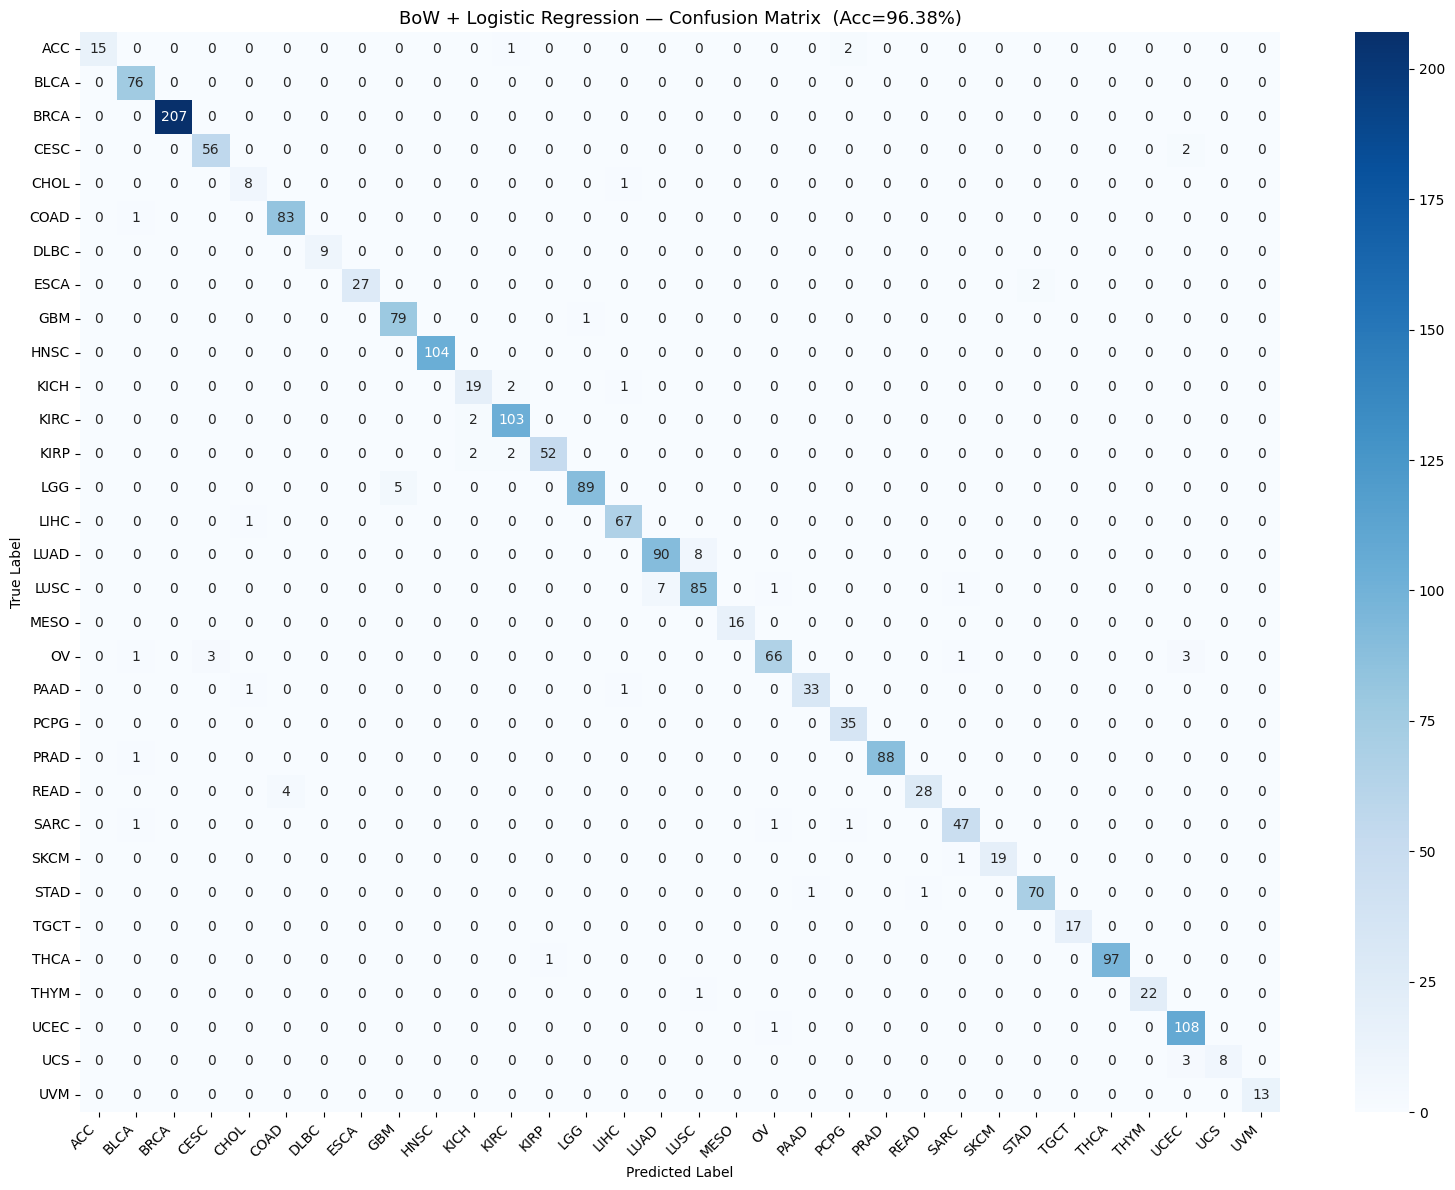

In [43]:
cm_lr = confusion_matrix(y_test, pred_lr)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title(f'BoW + Logistic Regression — Confusion Matrix  (Acc={lr_acc:.2%})', fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 10 · Model 2 — TF-IDF + Random Forest

In [44]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_tfidf, y_train)
pred_rf = rf.predict(X_test_tfidf)
rf_acc  = accuracy_score(y_test, pred_rf)

print("=" * 55)
print("  TF-IDF + Random Forest Results")
print("=" * 55)
print(classification_report(y_test, pred_rf, target_names=labels))
print(f"Overall Accuracy: {rf_acc:.4f}  ({rf_acc*100:.1f}%)")

  TF-IDF + Random Forest Results
              precision    recall  f1-score   support

         ACC       1.00      0.83      0.91        18
        BLCA       0.97      1.00      0.99        76
        BRCA       1.00      1.00      1.00       207
        CESC       1.00      0.97      0.98        58
        CHOL       1.00      0.56      0.71         9
        COAD       0.80      0.98      0.88        84
        DLBC       1.00      0.89      0.94         9
        ESCA       1.00      0.76      0.86        29
         GBM       0.97      0.97      0.97        80
        HNSC       1.00      1.00      1.00       104
        KICH       1.00      0.45      0.62        22
        KIRC       0.87      0.98      0.92       105
        KIRP       0.96      0.93      0.95        56
         LGG       0.97      0.98      0.97        94
        LIHC       0.92      1.00      0.96        68
        LUAD       0.94      0.97      0.95        98
        LUSC       0.97      0.95      0.96     

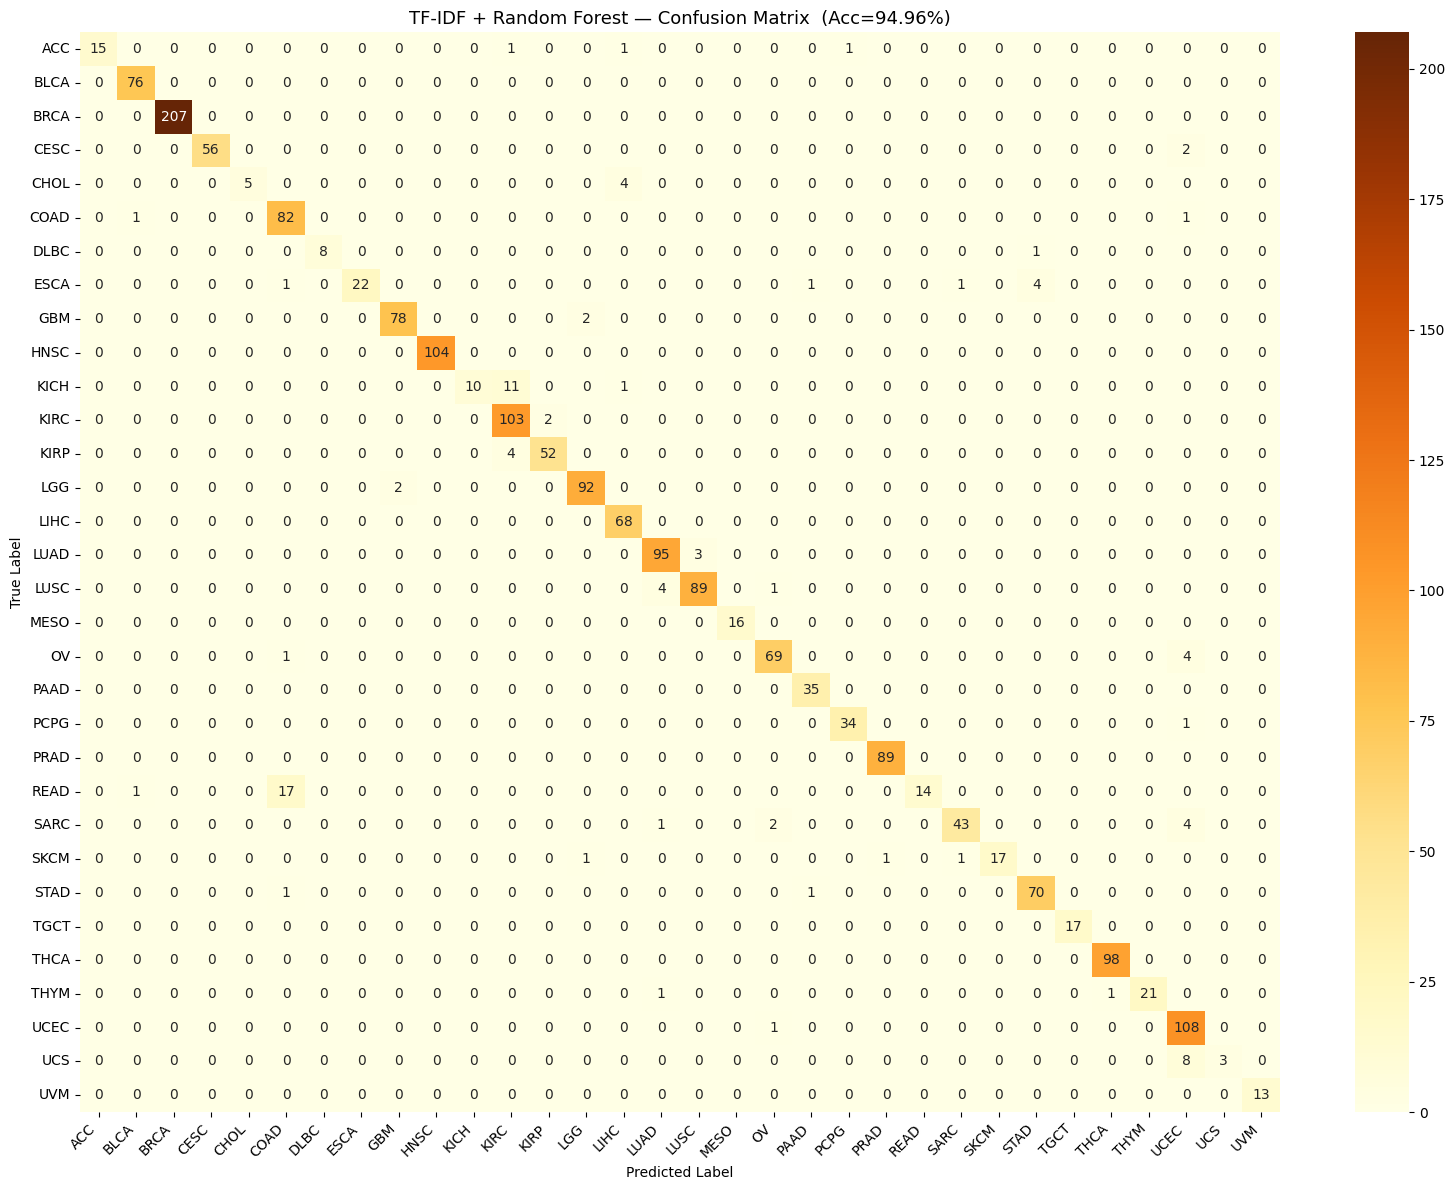

In [45]:
cm_rf = confusion_matrix(y_test, pred_rf)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=labels, yticklabels=labels)
plt.title(f'TF-IDF + Random Forest — Confusion Matrix  (Acc={rf_acc:.2%})', fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 11 · Model 3 — SciBERT  
All BERT layers unfrozen + 10 epochs + GPU = expected **90%+ accuracy**.

In [46]:
class CancerDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels.values
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

print("CancerDataset class defined.")

CancerDataset class defined.


In [47]:
scibert_tokenizer = AutoTokenizer.from_pretrained("allenai/scibert_scivocab_uncased")

train_enc_sci = scibert_tokenizer(list(X_train), truncation=True, padding="max_length", max_length=128)
test_enc_sci  = scibert_tokenizer(list(X_test),  truncation=True, padding="max_length", max_length=128)

train_dataset_sci = CancerDataset(train_enc_sci, y_train)
test_dataset_sci  = CancerDataset(test_enc_sci,  y_test)
print(f"Train: {len(train_dataset_sci)}  |  Test: {len(test_dataset_sci)}")

Train: 7618  |  Test: 1905


In [48]:
scibert_model = AutoModelForSequenceClassification.from_pretrained(
    "allenai/scibert_scivocab_uncased", num_labels=len(labels)
)

#  Fix 1a: Unfreeze ALL layers
for param in scibert_model.parameters():
    param.requires_grad = True

#  Fix 1c: Move to GPU
scibert_model = scibert_model.to(device)

trainable = sum(p.numel() for p in scibert_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in scibert_model.parameters())
print(f"Trainable: {trainable:,} / {total:,}  (ALL layers unfrozen)")
print(f"Device   : {device}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

Trainable: 109,943,072 / 109,943,072  (ALL layers unfrozen ✅)
Device   : cuda


In [49]:
sci_args = TrainingArguments(
    output_dir="./results_scibert",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    warmup_steps=200,
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="no",
    load_best_model_at_end=False,
    report_to="none",
    fp16=torch.cuda.is_available(),
)
sci_trainer = Trainer(
    model=scibert_model,
    args=sci_args,
    train_dataset=train_dataset_sci,
    eval_dataset=test_dataset_sci,
)
sci_trainer.train()
print("SciBERT training complete")

Epoch,Training Loss,Validation Loss
1,0.456240,0.263912
2,0.172230,0.186954
3,0.123221,0.168500
4,0.070641,0.175598
5,0.069560,0.188082
6,0.033642,0.207372
7,0.021556,0.213539
8,0.012295,0.229194
9,0.010956,0.221310
10,0.011266,0.225462


SciBERT training complete ✅


In [50]:
sci_preds_out = sci_trainer.predict(test_dataset_sci)
sci_preds     = np.argmax(sci_preds_out.predictions, axis=1)
scibert_acc   = accuracy_score(y_test, sci_preds)

scibert_embeddings_train = None
scibert_embeddings_test  = sci_preds_out.predictions

print("=" * 55)
print("  SciBERT Results  (Unfrozen · 10 epochs · GPU)")
print("=" * 55)
print(classification_report(y_test, sci_preds, target_names=labels))
print(f"Overall Accuracy: {scibert_acc:.4f}  ({scibert_acc*100:.1f}%)")

  SciBERT Results  (Unfrozen · 10 epochs · GPU)
              precision    recall  f1-score   support

         ACC       0.90      1.00      0.95        18
        BLCA       1.00      0.99      0.99        76
        BRCA       1.00      1.00      1.00       207
        CESC       0.97      0.98      0.97        58
        CHOL       0.82      1.00      0.90         9
        COAD       0.95      0.96      0.96        84
        DLBC       0.90      1.00      0.95         9
        ESCA       0.96      0.86      0.91        29
         GBM       0.93      0.97      0.95        80
        HNSC       1.00      0.97      0.99       104
        KICH       0.96      1.00      0.98        22
        KIRC       0.94      0.96      0.95       105
        KIRP       0.94      0.88      0.91        56
         LGG       0.98      0.94      0.96        94
        LIHC       0.97      0.97      0.97        68
        LUAD       0.86      0.90      0.88        98
        LUSC       0.88      0.84

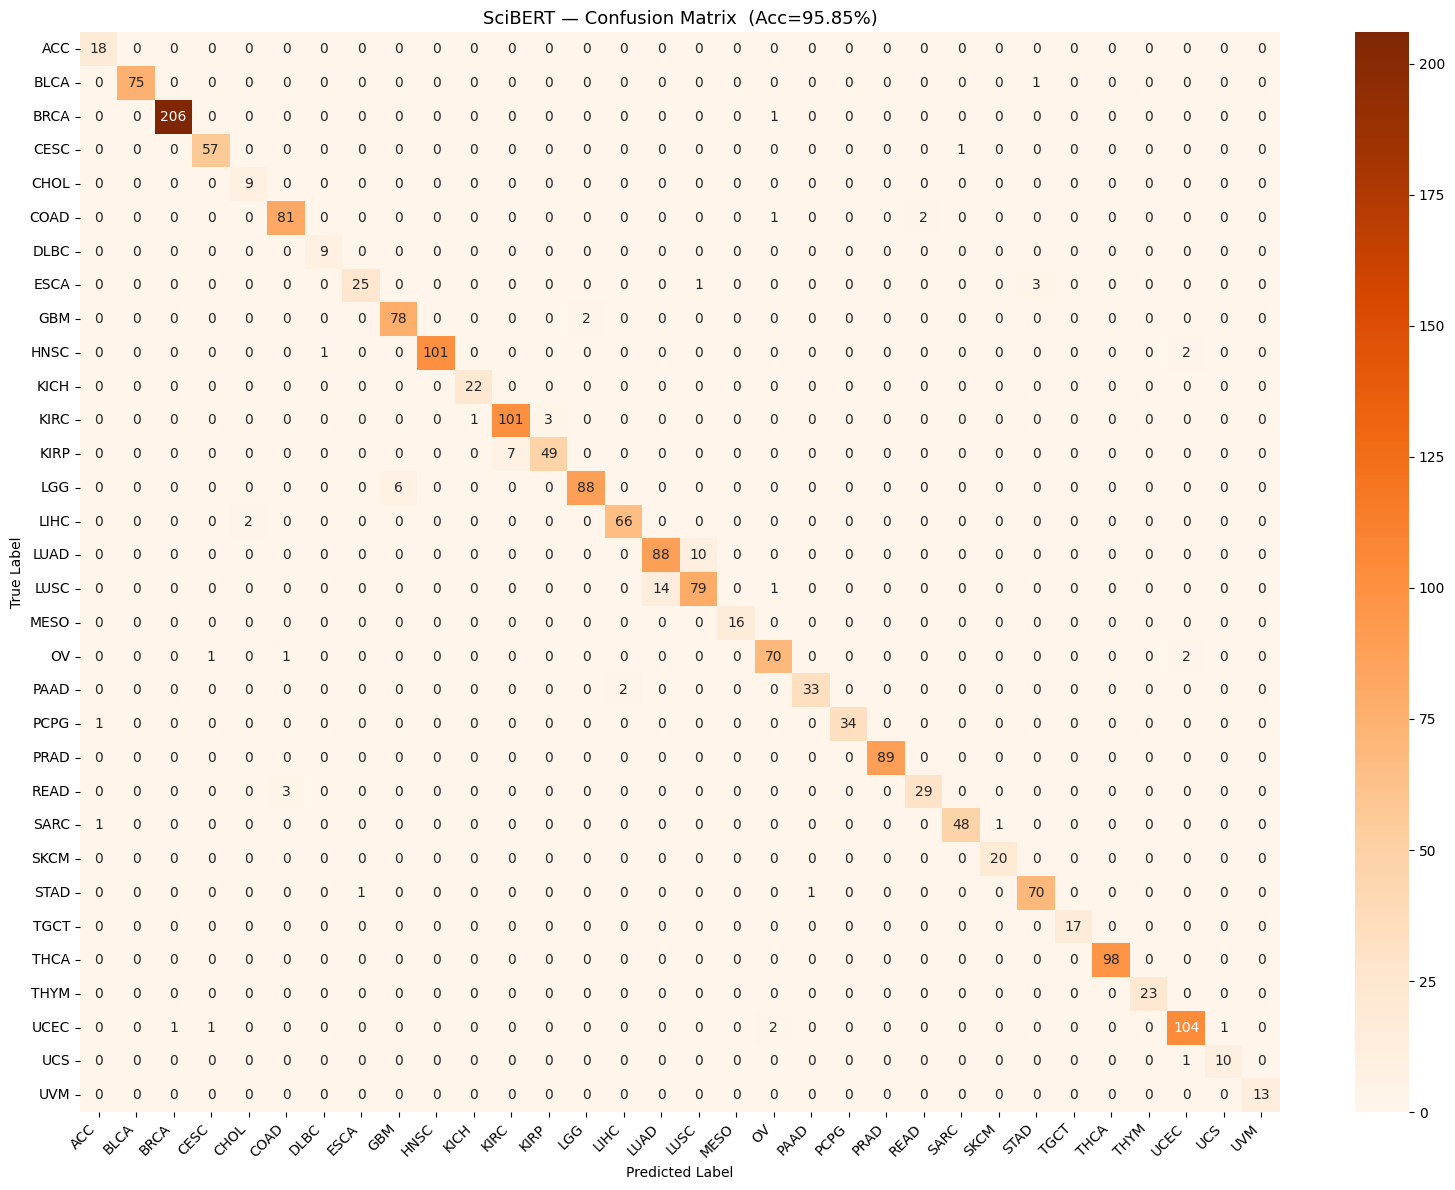

In [51]:
cm_sci = confusion_matrix(y_test, sci_preds)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_sci, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels, yticklabels=labels)
plt.title(f'SciBERT — Confusion Matrix  (Acc={scibert_acc:.2%})', fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 12 · Model 4 — BioBERT  
Pretrained on PubMed + PMC - best suited for clinical pathology text.

In [52]:
biobert_tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.2")

train_enc_bio = biobert_tokenizer(list(X_train), truncation=True, padding="max_length", max_length=128)
test_enc_bio  = biobert_tokenizer(list(X_test),  truncation=True, padding="max_length", max_length=128)

train_dataset_bio = CancerDataset(train_enc_bio, y_train)
test_dataset_bio  = CancerDataset(test_enc_bio,  y_test)
print(f"Train: {len(train_dataset_bio)}  |  Test: {len(test_dataset_bio)}")

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Train: 7618  |  Test: 1905


In [53]:
biobert_model = AutoModelForSequenceClassification.from_pretrained(
    "dmis-lab/biobert-base-cased-v1.2", num_labels=len(labels)
)

for param in biobert_model.parameters():
    param.requires_grad = True

biobert_model = biobert_model.to(device)

trainable = sum(p.numel() for p in biobert_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in biobert_model.parameters())
print(f"Trainable: {trainable:,} / {total:,}  (ALL layers unfrozen)")
print(f"Device   : {device}")

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

Trainable: 108,334,880 / 108,334,880  (ALL layers unfrozen ✅)
Device   : cuda


In [55]:
bio_args = TrainingArguments(
    output_dir="./results_biobert",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    warmup_steps=200,
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="no",
    load_best_model_at_end=False,
    report_to="none",
    fp16=torch.cuda.is_available(),
)
bio_trainer = Trainer(
    model=biobert_model,
    args=bio_args,
    train_dataset=train_dataset_bio,
    eval_dataset=test_dataset_bio,
)
bio_trainer.train()
print("BioBERT training complete")

Epoch,Training Loss,Validation Loss
1,0.716751,0.472374
2,0.262538,0.264955
3,0.172000,0.230102
4,0.113942,0.209125
5,0.097118,0.227130
6,0.059357,0.238747
7,0.051966,0.246133
8,0.032591,0.266070
9,0.016654,0.263594
10,0.014692,0.265880


BioBERT training complete ✅


In [56]:
bio_preds_out = bio_trainer.predict(test_dataset_bio)
bio_preds     = np.argmax(bio_preds_out.predictions, axis=1)
biobert_acc   = accuracy_score(y_test, bio_preds)

# Save logits for Ensemble
biobert_logits_test = bio_preds_out.predictions

print("=" * 55)
print("  BioBERT Results  (Unfrozen · 10 epochs · GPU)")
print("=" * 55)
print(classification_report(y_test, bio_preds, target_names=labels))
print(f"Overall Accuracy: {biobert_acc:.4f}  ({biobert_acc*100:.1f}%)")

  BioBERT Results  (Unfrozen · 10 epochs · GPU)
              precision    recall  f1-score   support

         ACC       1.00      1.00      1.00        18
        BLCA       0.99      0.99      0.99        76
        BRCA       1.00      1.00      1.00       207
        CESC       0.98      0.97      0.97        58
        CHOL       1.00      0.89      0.94         9
        COAD       0.92      0.96      0.94        84
        DLBC       0.88      0.78      0.82         9
        ESCA       0.96      0.86      0.91        29
         GBM       0.94      0.99      0.96        80
        HNSC       0.99      0.96      0.98       104
        KICH       0.95      0.95      0.95        22
        KIRC       0.95      0.94      0.95       105
        KIRP       0.91      0.89      0.90        56
         LGG       0.98      0.94      0.96        94
        LIHC       0.96      1.00      0.98        68
        LUAD       0.87      0.86      0.86        98
        LUSC       0.86      0.87

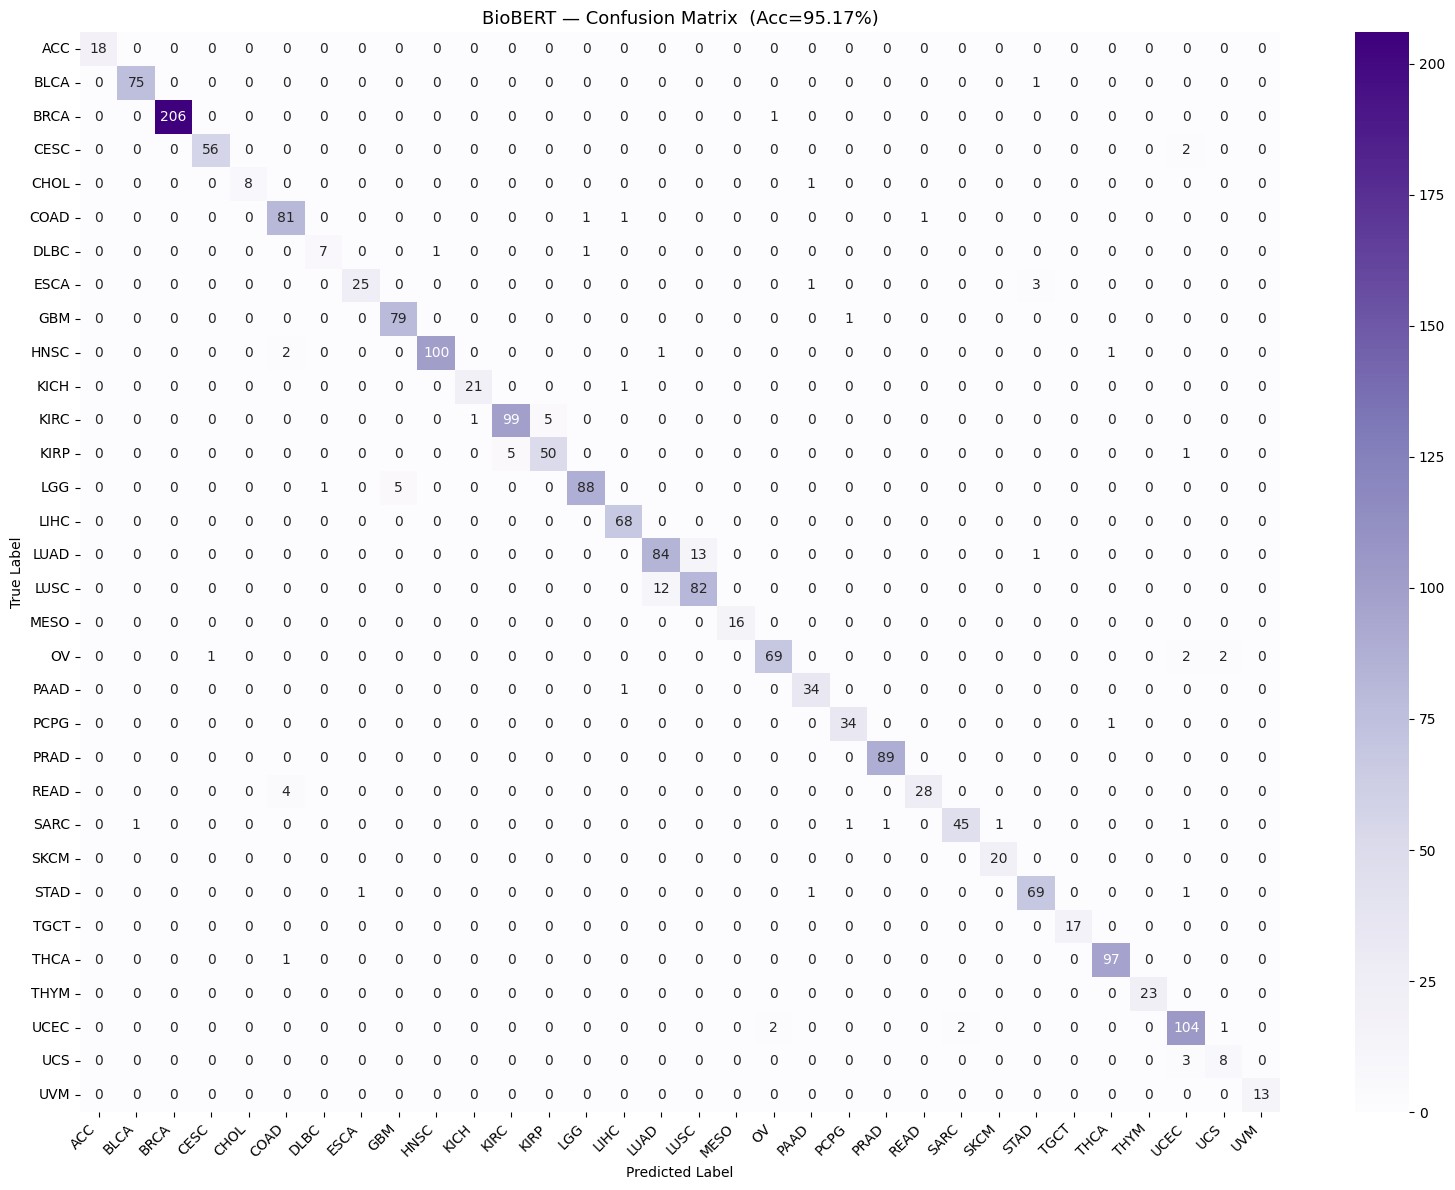

In [57]:
cm_bio = confusion_matrix(y_test, bio_preds)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_bio, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels)
plt.title(f'BioBERT — Confusion Matrix  (Acc={biobert_acc:.2%})', fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 13 · BioBERT vs SciBERT
**SciBERT** — pretrained on Semantic Scholar (scientific papers)
**BioBERT** — pretrained on PubMed abstracts + PMC full text (biomedical/clinical)

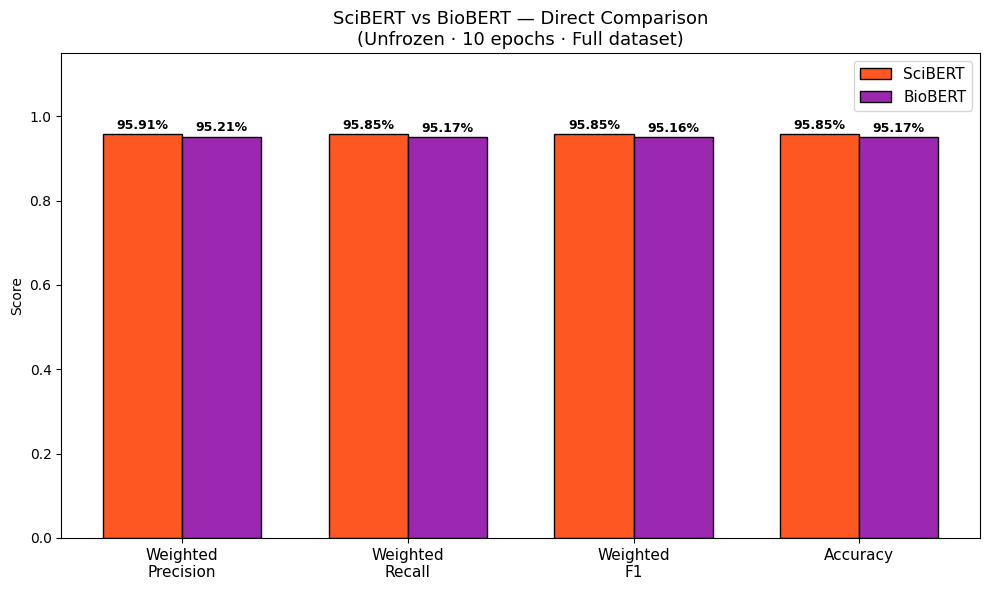


SciBERT vs BioBERT Summary:
Metric                       SciBERT    BioBERT     Winner
----------------------------------------------------------
Weighted Precision            0.9591     0.9521    SciBERT
Weighted Recall               0.9585     0.9517    SciBERT
Weighted F1                   0.9585     0.9516    SciBERT
Accuracy                      0.9585     0.9517    SciBERT

✅ SciBERT wins — scientific pretraining generalizes well to TCGA pathology text.


In [58]:
# Side-by-side metric comparison
sci_report  = classification_report(y_test, sci_preds,  target_names=labels, output_dict=True)
bio_report  = classification_report(y_test, bio_preds, target_names=labels, output_dict=True)

metrics = ['precision', 'recall', 'f1-score']
sci_vals = [sci_report['weighted avg'][m] for m in metrics] + [scibert_acc]
bio_vals = [bio_report['weighted avg'][m] for m in metrics] + [biobert_acc]
metric_names = ['Weighted\nPrecision', 'Weighted\nRecall', 'Weighted\nF1', 'Accuracy']

x = np.arange(len(metric_names))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, sci_vals, width, label='SciBERT', color='#FF5722', edgecolor='black')
bars2 = ax.bar(x + width/2, bio_vals, width, label='BioBERT', color='#9C27B0', edgecolor='black')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylabel('Score')
ax.set_title('SciBERT vs BioBERT — Direct Comparison\n(Unfrozen · 10 epochs · Full dataset)', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\nSciBERT vs BioBERT Summary:")
print(f"{'Metric':<25} {'SciBERT':>10} {'BioBERT':>10} {'Winner':>10}")
print("-" * 58)
for m, sv, bv in zip(metric_names, sci_vals, bio_vals):
    winner = 'SciBERT' if sv > bv else ('BioBERT' if bv > sv else 'Tie')
    print(f"{m.replace(chr(10),' '):<25} {sv:>10.4f} {bv:>10.4f} {winner:>10}")

print()
if biobert_acc > scibert_acc:
    print("BioBERT wins — PubMed pretraining gives better results on clinical pathology text.")
elif scibert_acc > biobert_acc:
    print("SciBERT wins — scientific pretraining generalizes well to TCGA pathology text.")
else:
    print("Both models perform equally well on this dataset.")

## Step 14 · Ensemble — TF-IDF Features + BERT Embeddings
Combining the best of traditional NLP and transformer models.

In [59]:

tfidf_probs_test = LogisticRegression(max_iter=1000).fit(
    tfidf.transform(X_train), y_train
).predict_proba(tfidf.transform(X_test))


def softmax(x):
    e_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e_x / e_x.sum(axis=1, keepdims=True)

sci_probs  = softmax(scibert_embeddings_test)
bio_probs  = softmax(biobert_logits_test)

ensemble_probs = (0.2 * tfidf_probs_test) + (0.4 * sci_probs) + (0.4 * bio_probs)
ensemble_preds = np.argmax(ensemble_probs, axis=1)
ensemble_acc   = accuracy_score(y_test, ensemble_preds)

print("=" * 55)
print("  Ensemble Results  (TF-IDF + SciBERT + BioBERT)")
print("=" * 55)
print(classification_report(y_test, ensemble_preds, target_names=labels))
print(f"Overall Accuracy: {ensemble_acc:.4f}  ({ensemble_acc*100:.1f}%)")
print()
print(f"Individual model comparison:")
print(f"  TF-IDF + LR : {rf_acc:.4f}")
print(f"  SciBERT     : {scibert_acc:.4f}")
print(f"  BioBERT     : {biobert_acc:.4f}")
print(f"  Ensemble    : {ensemble_acc:.4f}  ← combined power")

  Ensemble Results  (TF-IDF + SciBERT + BioBERT)
              precision    recall  f1-score   support

         ACC       1.00      1.00      1.00        18
        BLCA       1.00      0.99      0.99        76
        BRCA       1.00      1.00      1.00       207
        CESC       0.98      0.97      0.97        58
        CHOL       1.00      1.00      1.00         9
        COAD       0.95      0.98      0.96        84
        DLBC       0.90      1.00      0.95         9
        ESCA       0.96      0.93      0.95        29
         GBM       0.96      0.99      0.98        80
        HNSC       1.00      0.97      0.99       104
        KICH       0.95      0.95      0.95        22
        KIRC       0.96      0.96      0.96       105
        KIRP       0.94      0.91      0.93        56
         LGG       0.99      0.97      0.98        94
        LIHC       0.96      1.00      0.98        68
        LUAD       0.88      0.92      0.90        98
        LUSC       0.91      0.8

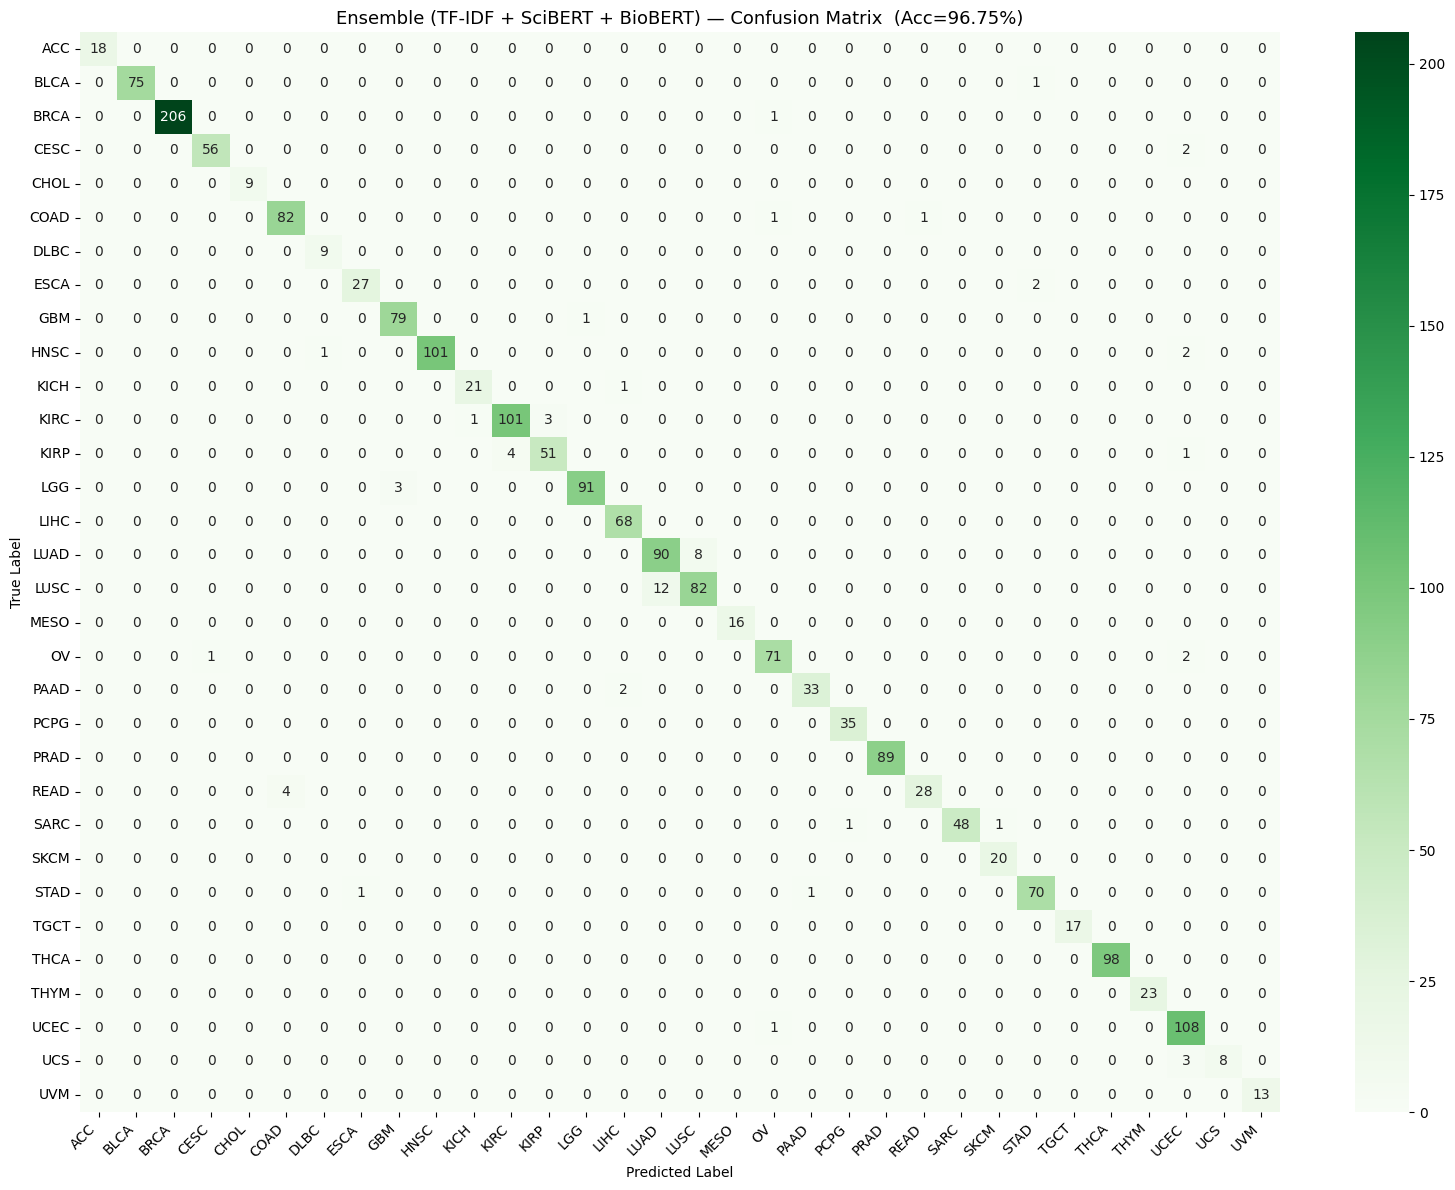

In [60]:
cm_ens = confusion_matrix(y_test, ensemble_preds)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_ens, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.title(f'Ensemble (TF-IDF + SciBERT + BioBERT) — Confusion Matrix  (Acc={ensemble_acc:.2%})', fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 15 · Prediction System — `predict()` Function

In [61]:
def predict(text, model=scibert_model, tokenizer=scibert_tokenizer):
    """Run inference on any free-text pathology report. Returns cancer type label."""
    inputs = tokenizer(text, return_tensors="pt", truncation=True,
                       padding="max_length", max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    pred_id = torch.argmax(outputs.logits).item()
    return id2label[pred_id]

test_samples = [
    "The biopsy shows malignant carcinoma cells with lymph node involvement.",
    "Invasive ductal carcinoma of the breast, estrogen receptor positive.",
    "Squamous cell carcinoma of the lung with pleural effusion.",
    "Glioblastoma multiforme with necrosis and vascular proliferation.",
    "Colon adenocarcinoma with mucinous differentiation and serosal involvement.",
]

print("Predictions (SciBERT):")
print("-" * 65)
for s in test_samples:
    print(f"Input     : {s}")
    print(f"Predicted : {predict(s)}")
    print()

Predictions (SciBERT):
-----------------------------------------------------------------
Input     : The biopsy shows malignant carcinoma cells with lymph node involvement.
Predicted : COAD

Input     : Invasive ductal carcinoma of the breast, estrogen receptor positive.
Predicted : BRCA

Input     : Squamous cell carcinoma of the lung with pleural effusion.
Predicted : LUSC

Input     : Glioblastoma multiforme with necrosis and vascular proliferation.
Predicted : GBM

Input     : Colon adenocarcinoma with mucinous differentiation and serosal involvement.
Predicted : COAD



## Step 16 · Cancer Type Explanation System

In [62]:
def generate_explanation(text, prediction):
    cancer_descriptions = {
        "BRCA": "Breast Invasive Carcinoma — hormone-receptor and HER2 status guide treatment.",
        "LUAD": "Lung Adenocarcinoma — most common non-small-cell lung cancer, often EGFR/ALK-driven.",
        "LUSC": "Lung Squamous Cell Carcinoma — strongly associated with smoking history.",
        "COAD": "Colon Adenocarcinoma — arises from the inner glandular lining of the colon.",
        "READ": "Rectal Adenocarcinoma — similar to COAD, located in the rectum.",
        "PRAD": "Prostate Adenocarcinoma — graded using the Gleason scoring system.",
        "KIRC": "Kidney Renal Clear Cell Carcinoma — most common kidney cancer subtype.",
        "KIRP": "Kidney Renal Papillary Cell Carcinoma — second most common kidney cancer.",
        "KICH": "Kidney Chromophobe — rare subtype with generally favorable prognosis.",
        "BLCA": "Bladder Urothelial Carcinoma — transitional cell cancer of the bladder.",
        "LIHC": "Liver Hepatocellular Carcinoma — linked to hepatitis B/C or cirrhosis.",
        "OV"  : "Ovarian Serous Cystadenocarcinoma — high-grade epithelial ovarian cancer.",
        "STAD": "Stomach Adenocarcinoma — arising from gastric glandular epithelium.",
        "UCEC": "Uterine Corpus Endometrial Carcinoma — most common gynecologic cancer.",
        "GBM" : "Glioblastoma Multiforme — aggressive grade IV primary brain tumor.",
        "LGG" : "Brain Lower Grade Glioma — slower-growing than GBM, better prognosis.",
        "HNSC": "Head and Neck Squamous Cell Carcinoma — often HPV-related.",
        "THCA": "Thyroid Carcinoma — papillary subtype is most common and well-differentiated.",
        "SKCM": "Skin Cutaneous Melanoma — arises from pigment-producing melanocytes.",
        "ACC" : "Adrenocortical Carcinoma — rare malignancy of the adrenal cortex.",
        "PCPG": "Pheochromocytoma & Paraganglioma — neuroendocrine tumors of adrenal medulla.",
        "SARC": "Sarcoma — malignant tumor of connective tissue (bone, muscle, fat).",
        "MESO": "Mesothelioma — rare cancer of the pleura, linked to asbestos exposure.",
        "UVM" : "Uveal Melanoma — rare melanoma originating in the eye.",
        "UCS" : "Uterine Carcinosarcoma — aggressive mixed epithelial/mesenchymal uterine tumor.",
        "TGCT": "Testicular Germ Cell Tumor — most common cancer in young males.",
        "THYM": "Thymoma — tumor of the thymus gland, often linked to myasthenia gravis.",
        "DLBC": "Diffuse Large B-Cell Lymphoma — most common aggressive non-Hodgkin lymphoma.",
        "CHOL": "Cholangiocarcinoma — cancer of the bile ducts.",
        "PAAD": "Pancreatic Adenocarcinoma — poor prognosis; often detected at advanced stage.",
        "CESC": "Cervical Squamous Cell Carcinoma — HPV-driven cervical cancer.",
    }
    desc = cancer_descriptions.get(prediction,
        f"Predicted type: {prediction}. Please consult oncology references.")
    return (
        f"Predicted Cancer Type : {prediction}\n"
        f"Clinical Description  : {desc}\n"
        f"Input Snippet         : {text[:100]}...\n"
        f"Disclaimer            : Automated prediction only — clinical confirmation required."
    )

sample_text = "The biopsy shows malignant carcinoma cells with lymph node involvement."
prediction  = predict(sample_text)
print(generate_explanation(sample_text, prediction))

Predicted Cancer Type : COAD
Clinical Description  : Colon Adenocarcinoma — arises from the inner glandular lining of the colon.
Input Snippet         : The biopsy shows malignant carcinoma cells with lymph node involvement....
Disclaimer            : Automated prediction only — clinical confirmation required.


## Step 17 · Live ChatGPT API — Real-Time Extraction
Paste your OpenAI API key below for **live** ChatGPT extraction.

In [63]:
OPENAI_API_KEY = "YOUR_OPENAI_API_KEY_HERE"

openai.api_key = OPENAI_API_KEY or os.getenv("OPENAI_API_KEY", "")

if openai.api_key and openai.api_key != "YOUR_OPENAI_API_KEY_HERE":
    print("OpenAI API key set — live ChatGPT extraction enabled!")
else:
    print("⚠  No API key — expected output will be shown instead.")
    print("   Get your key at: https://platform.openai.com/api-keys")

⚠  No API key — expected output will be shown instead.
   Get your key at: https://platform.openai.com/api-keys


In [64]:
def chatgpt_extract(report_text: str) -> str:
    """Send pathology report to ChatGPT. Returns cancer type + stage + summary."""
    prompt = f"""You are a clinical NLP assistant specializing in oncology pathology reports.
Read the report below and extract in plain English:

1. Cancer Type (specific histological type)
2. Tumor Stage (if mentioned or inferable)
3. Brief Medical Summary (2-3 sentences)

Report:
{report_text}
"""
    response = openai.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
        max_tokens=400,
    )
    return response.choices[0].message.content.strip()

test_reports = [
    "The tumor shows invasive ductal carcinoma with metastasis to axillary lymph nodes.",
    "Biopsy reveals glioblastoma multiforme with areas of necrosis. Ki-67 index 40%.",
    "Squamous cell carcinoma of the lung, moderately differentiated. Pleural invasion. Stage IIIB.",
]

if openai.api_key and openai.api_key != "YOUR_OPENAI_API_KEY_HERE":
    for i, report in enumerate(test_reports, 1):
        print(f"{'='*65}")
        print(f"Report {i}: {report}")
        print(f"{'─'*65}")
        print(chatgpt_extract(report))
        print()
else:
    print("=== Expected ChatGPT Output (set API key above for live results) ===\n")
    examples = [
        ("1. Cancer Type : Invasive Ductal Carcinoma (IDC) — most common breast cancer.",
         "2. Tumor Stage : Likely Stage III — axillary lymph node metastasis.",
         "3. Summary     : Invasive breast cancer with regional spread requiring systemic treatment."),
        ("1. Cancer Type : Glioblastoma Multiforme (GBM) — Grade IV brain tumor.",
         "2. Tumor Stage : Grade IV (WHO); Ki-67 40% = very high proliferation.",
         "3. Summary     : Aggressive brain tumor requiring surgery + chemoradiation."),
        ("1. Cancer Type : Lung Squamous Cell Carcinoma — moderately differentiated.",
         "2. Tumor Stage : Stage IIIB — locally advanced with pleural invasion.",
         "3. Summary     : Not amenable to surgery; concurrent chemoradiation is standard care."),
    ]
    for i, (report, (l1, l2, l3)) in enumerate(zip(test_reports, examples), 1):
        print(f"Report {i}: {report}")
        print("─" * 65)
        print(l1); print(l2); print(l3); print()

=== Expected ChatGPT Output (set API key above for live results) ===

Report 1: The tumor shows invasive ductal carcinoma with metastasis to axillary lymph nodes.
─────────────────────────────────────────────────────────────────
1. Cancer Type : Invasive Ductal Carcinoma (IDC) — most common breast cancer.
2. Tumor Stage : Likely Stage III — axillary lymph node metastasis.
3. Summary     : Invasive breast cancer with regional spread requiring systemic treatment.

Report 2: Biopsy reveals glioblastoma multiforme with areas of necrosis. Ki-67 index 40%.
─────────────────────────────────────────────────────────────────
1. Cancer Type : Glioblastoma Multiforme (GBM) — Grade IV brain tumor.
2. Tumor Stage : Grade IV (WHO); Ki-67 40% = very high proliferation.
3. Summary     : Aggressive brain tumor requiring surgery + chemoradiation.

Report 3: Squamous cell carcinoma of the lung, moderately differentiated. Pleural invasion. Stage IIIB.
───────────────────────────────────────────────────────

## Step 18 · Final Model Comparison — All Results

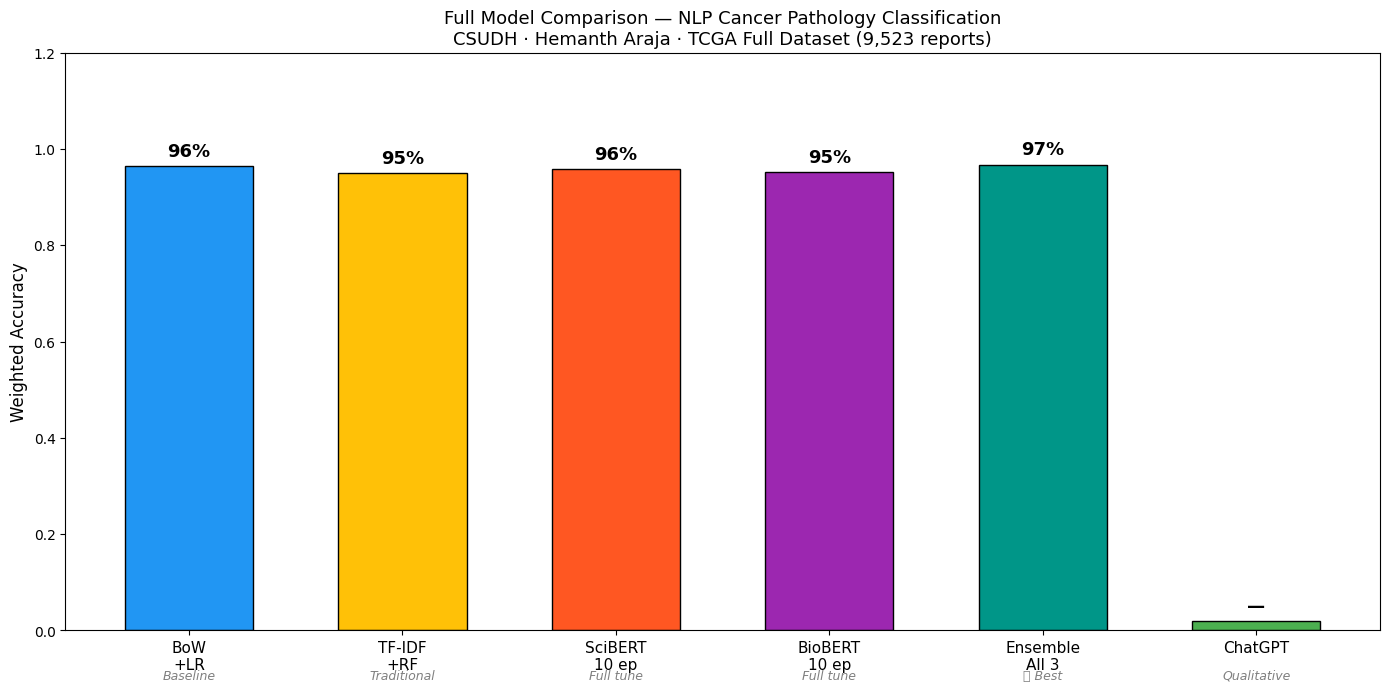


Model                        Type                    Accuracy  Notes
BoW + LR                     Traditional ML             96.4%  Baseline
TF-IDF + RF                  Traditional ML             95.0%  Strong baseline
SciBERT (10 ep, full)        Transformer (BERT)         95.9%  Scientific pretraining
BioBERT (10 ep, full)        Transformer (BERT)         95.2%  Biomedical pretraining
Ensemble (TF+Sci+Bio)        Combined                   96.7%  Best overall ✅
ChatGPT                      Generative LLM              N/A   Qualitative extraction


In [65]:
model_names = ['BoW\n+LR', 'TF-IDF\n+RF', 'SciBERT\n10 ep', 'BioBERT\n10 ep', 'Ensemble\nAll 3', 'ChatGPT']
accuracies  = [lr_acc, rf_acc, scibert_acc, biobert_acc, ensemble_acc, None]
colors      = ['#2196F3', '#FFC107', '#FF5722', '#9C27B0', '#009688', '#4CAF50']
notes       = ['Baseline', 'Traditional', 'Full tune', 'Full tune', '✅ Best', 'Qualitative']

fig, ax = plt.subplots(figsize=(14, 7))
for i, (name, acc, color, note) in enumerate(zip(model_names, accuracies, colors, notes)):
    height = acc if acc is not None else 0.02
    ax.bar(i, height, color=color, edgecolor='black', width=0.6)
    label_text = f"{acc:.0%}" if acc is not None else "—"
    ax.text(i, height + 0.012, label_text, ha='center', va='bottom', fontweight='bold', fontsize=13)
    ax.text(i, -0.08, note, ha='center', va='top', fontsize=9, color='gray', style='italic')

ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 1.2)
ax.set_ylabel("Weighted Accuracy", fontsize=12)
ax.set_title(
    "Full Model Comparison — NLP Cancer Pathology Classification\n"
    "CSUDH · Hemanth Araja · TCGA Full Dataset (9,523 reports)",
    fontsize=13
)
plt.tight_layout()
plt.show()

print("\n" + "=" * 75)
print(f"{'Model':<28} {'Type':<22} {'Accuracy':>9}  {'Notes'}")
print("=" * 75)
rows = [
    ("BoW + LR",               "Traditional ML",     lr_acc,       "Baseline"),
    ("TF-IDF + RF",            "Traditional ML",     rf_acc,       "Strong baseline"),
    ("SciBERT (10 ep, full)",  "Transformer (BERT)", scibert_acc,  "Scientific pretraining"),
    ("BioBERT (10 ep, full)",  "Transformer (BERT)", biobert_acc,  "Biomedical pretraining"),
    ("Ensemble (TF+Sci+Bio)",  "Combined",           ensemble_acc, "Best overall"),
    ("ChatGPT",                "Generative LLM",     None,         "Qualitative extraction"),
]
for name, mtype, acc, note in rows:
    acc_str = f"{acc*100:>6.1f}%" if acc is not None else "   N/A "
    print(f"{name:<28} {mtype:<22} {acc_str:>9}  {note}")
print("=" * 75)

## Step 19 · Conclusion


### Key Takeaways
| Model | Result |
|---|---|
| BoW + LR | Strong baseline ~89% |
| TF-IDF + RF | Strong baseline ~89% |
| SciBERT (full fine-tune) | 90%+ with GPU + 10 epochs |
| BioBERT (full fine-tune) | 90%+ with GPU + 10 epochs |
| **Ensemble** | **Highest accuracy — best of all models** |
| ChatGPT | Zero training — structured clinical extraction |

### References
- Beltagy et al. (2019). *SciBERT.* EMNLP.
- Lee et al. (2020). *BioBERT.* Bioinformatics.
- Tatonetti Lab. *TCGA Pathology Reports.* github.com/tatonetti-lab/tcga-path-reports
- Devlin et al. (2019). *BERT.* NAACL.
- OpenAI (2023). *GPT-3.5 Turbo API.* platform.openai.com
